In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
df = pd.read_csv('../data/kenya.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [18]:
df['Country'] = 'Kenya'
df['Date'] = pd.to_datetime(df['YEAR']*1000+df['DOY'],format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [19]:
print(f"Number of -999 values before replacement: {(df == -999).sum().sum()}")

Number of -999 values before replacement: 0


In [20]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046,3.248907


In [ ]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df_outliers = df[weather_cols].copy()
z_scores= np.abs(stats.zscore(df_outliers))
outliers = (z_scores > 3)  #any check if there is any true value in column or rows
outlier_rows = outliers.any(axis=1).sum()
print(outlier_rows)

121


In [8]:
import os
makedir = os.makedirs('data',exist_ok=True)
df.to_csv('../data/kenya_clean.csv')

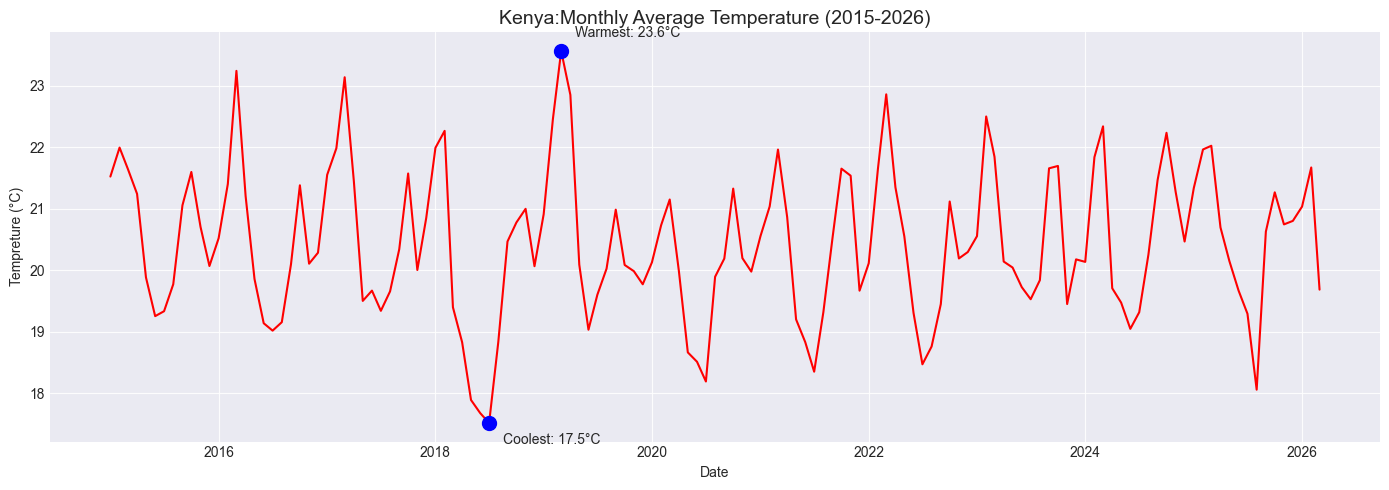

In [31]:
#plot for monthly kenya temprature data
monthly_temp = df.groupby(['Year','Month'])['T2M'].mean().reset_index()  #this creates a table called monthly_temp that holds average of each month of each year
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str)+'-'+monthly_temp['Month'].astype(str))

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_temp['Date'],monthly_temp['T2M'],color='red',linewidth=1.5)

warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

ax.scatter(warmest['Date'],warmest['T2M'],color='blue',s=100,zorder=5)
ax.scatter(coolest['Date'],coolest['T2M'],color='blue',s=100,zorder=5)

ax.set_title('Kenya:Monthly Average Temperature (2015-2026)',fontsize=14)
ax.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', 
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points', fontsize=10)

ax.annotate(f'Coolest: {coolest["T2M"]:.1f}°C',
            xy=(coolest['Date'], coolest['T2M']), #xy cordiante where the point will be
            xytext=(10, -15), textcoords='offset points', fontsize=10)

ax.set_xlabel('Date')
ax.set_ylabel('Tempreture (°C)')
ax.grid(True,alpha =0.9)

plt.tight_layout()
plt.show() 

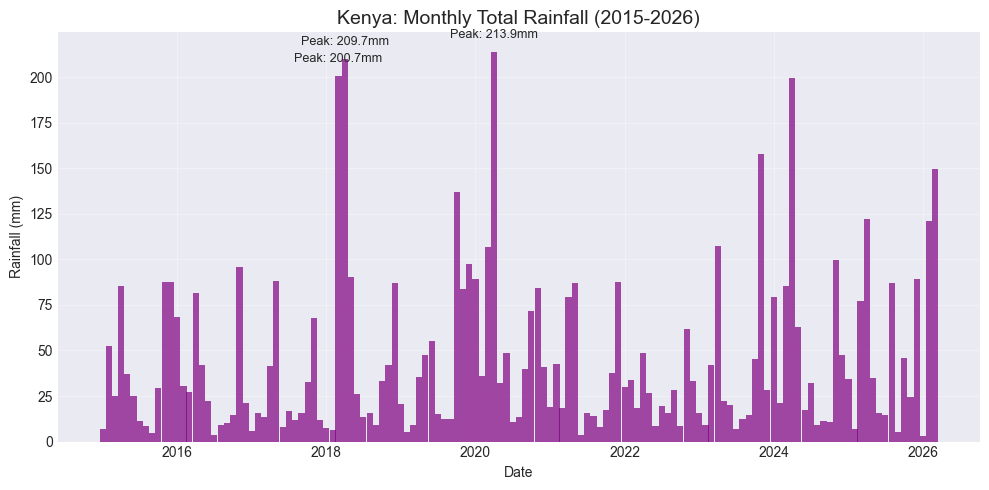

In [ ]:
#plot for monthly Kenyan rain graph
monthly_rain = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
monthly_rain['Date'] = pd.to_datetime(monthly_rain['Year'].astype(str)+'-'+monthly_rain['Month'].astype(str))

#let us plot the graph
fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(monthly_rain['Date'], monthly_rain['PRECTOTCORR'], width=30,color='purple',alpha=0.7)

peak_months = monthly_rain.nlargest(3, 'PRECTOTCORR')

for _, row in peak_months.iterrows():
    ax.annotate(f'Peak: {row["PRECTOTCORR"]:.1f}mm',
                xy=(row['Date'], row['PRECTOTCORR']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)

ax.set_title('Kenya: Monthly Total Rainfall (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall (mm)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

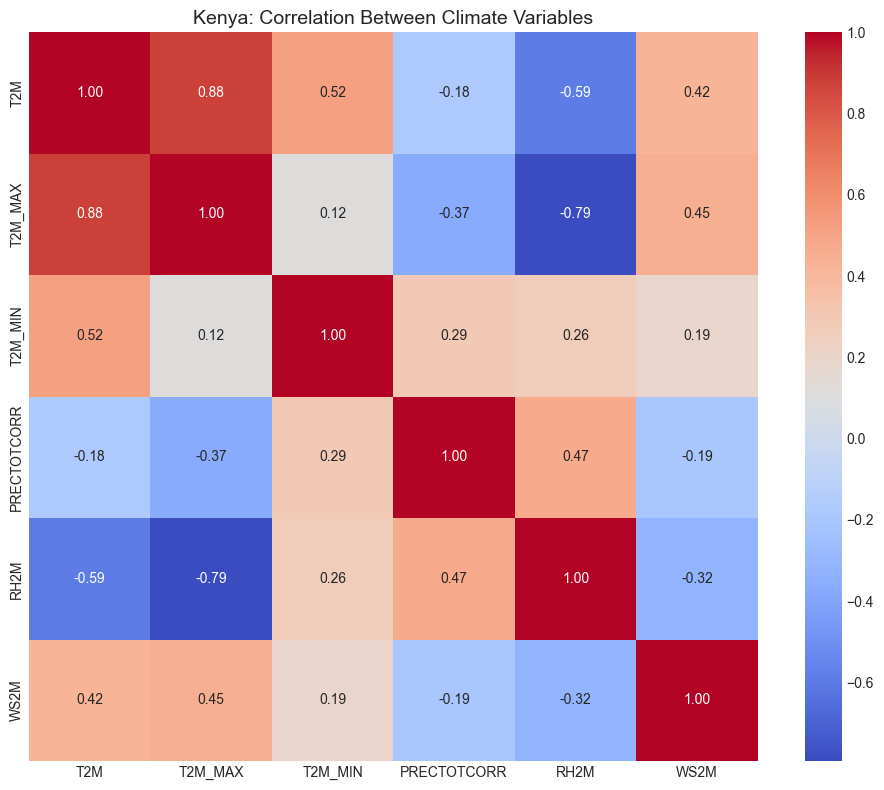

Three strongest correlations:
1. T2M_MAX vs T2M: 0.881
2. RH2M vs T2M_MAX: 0.793
3. RH2M vs T2M: 0.591


In [ ]:

corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True,
             cmap='coolwarm',
             center=0, 
            fmt='.2f', square=True, ax=ax)

ax.set_title('Kenya: Correlation Between Climate Variables', fontsize=14)

plt.tight_layout()
plt.show()

# Find strongest correlations
# Get upper triangle of correlation matrix (excluding diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corrs = upper_tri.unstack().dropna().abs().sort_values(ascending=False)


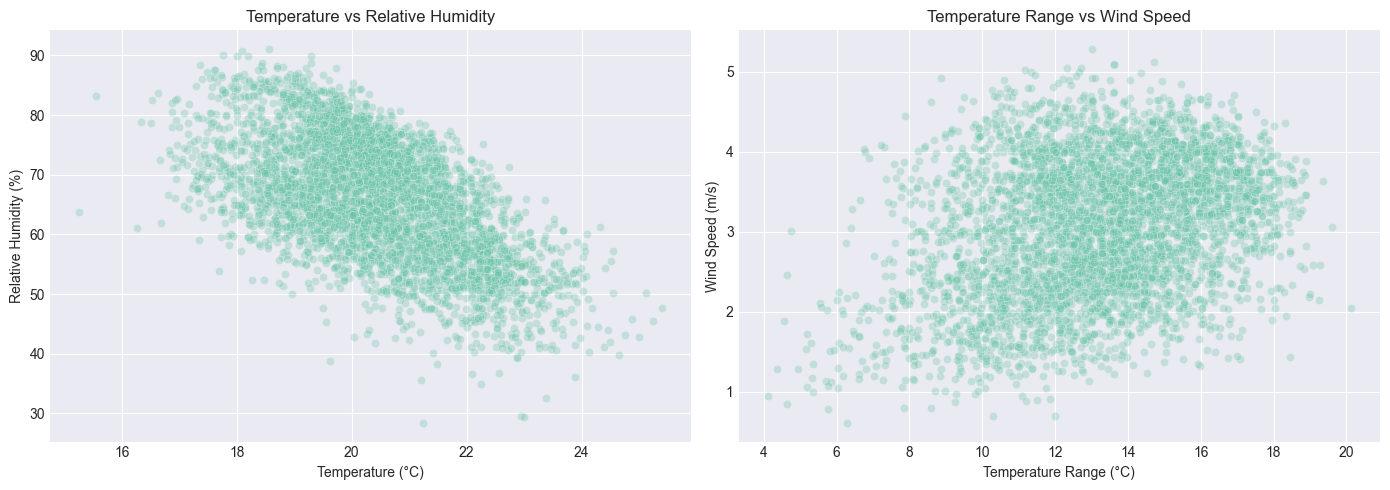

In [46]:
# Create scatter plots
fig, axes = plt.subplots(1, 2
                         ,figsize=(14, 5))

# Scatter 1: Temperature vs Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')

# Scatter 2: Temperature Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

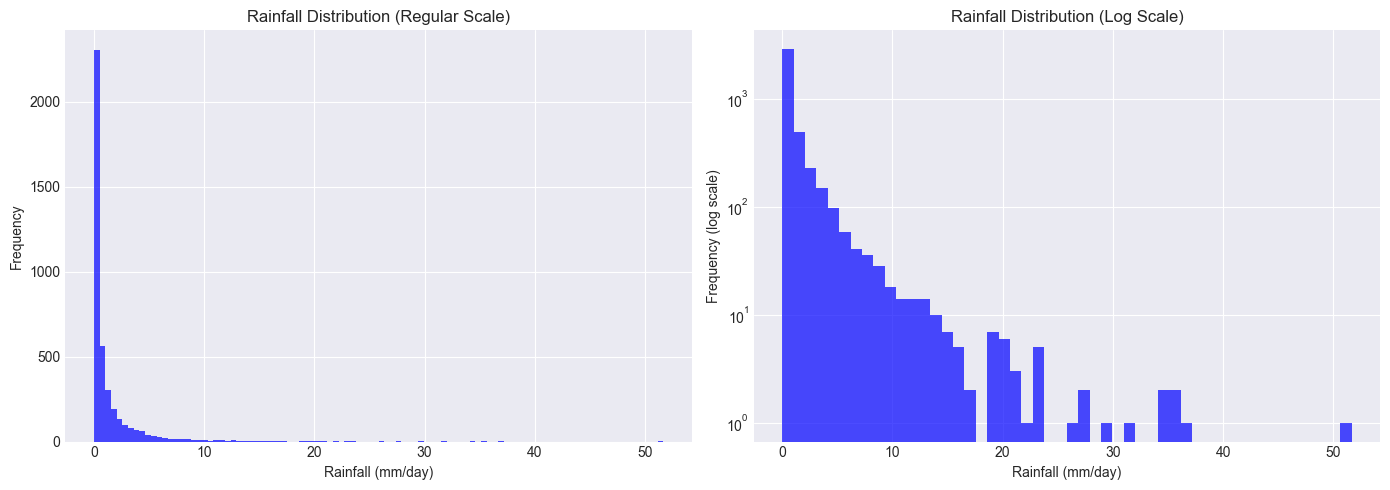

In [ ]:
# Rainfall histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular scale
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50
             , color='blue', alpha=0.7)
axes[0].set_title('Rainfall Distribution (Regular Scale)')
axes[0].set_xlabel('Rainfall (mm/day)')
axes[0].set_ylabel('Frequency')

# Log scale (to see pattern better)
axes[1].hist(df['PRECTOTCORR'].dropna(), bins=50, color='blue', alpha=0.7, log=True)
axes[1].set_title('Rainfall Distribution (Log Scale)')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

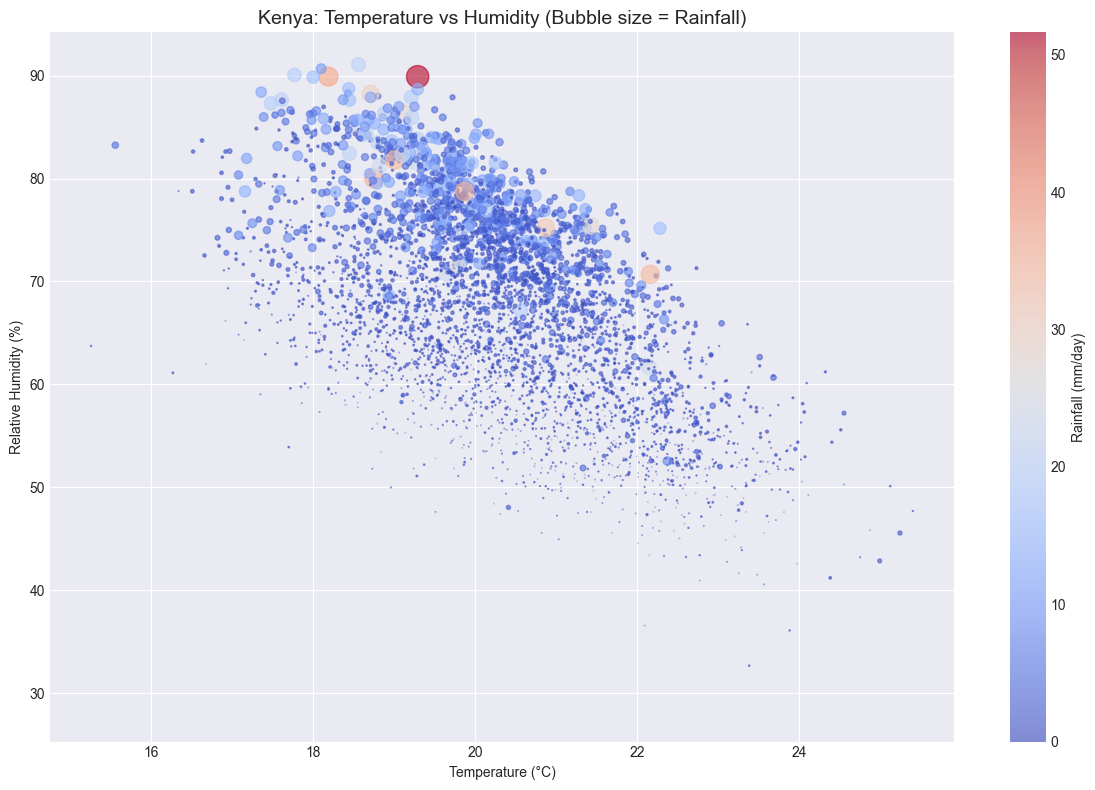

In [ ]:
# Bubble chart: Temperature vs Humidity, size = Rainfall
sample = df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR'])

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(sample['T2M'], sample['RH2M'], 
                     s=sample['PRECTOTCORR'] * 5,  # Size proportional to rainfall
                     alpha=0.6, c=sample['PRECTOTCORR'], cmap='coolwarm'
                     )

ax.set_title('Kenya: Temperature vs Humidity (Bubble size = Rainfall)', fontsize=14)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')

plt.colorbar(scatter, label='Rainfall (mm/day)')
plt.tight_layout()
plt.show()